# K-Means Clustering CA1

This notebook solves five clustering problem statements using K-Means:

- Q1: Airlines dataset
- Q2: Crime dataset
- Q3: Insurance policy dataset
- Q4: Telecom customer churn dataset (mixed features)
- Q5: Auto insurance dataset (mixed features)

Each question includes:
1. Data loading and quick inspection
2. Preprocessing
3. Optimal cluster search (Elbow + Silhouette)
4. K-Means model training and cluster labeling
5. Cluster profiling and visualization
6. Observations and business insights

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
def show_basic_info(df, name):
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    display(df.head())
    display(df.describe(include="all").transpose().head(15))


def evaluate_k_values(X, k_min=2, k_max=10, sample_size=3000):
    n_samples = X.shape[0]
    k_upper = min(k_max, max(k_min, n_samples - 1))
    ks = list(range(k_min, k_upper + 1))

    inertias = []
    silhouettes = []

    for k in ks:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)

        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X, labels, sample_size=min(sample_size, n_samples), random_state=RANDOM_STATE)
        else:
            sil = np.nan
        silhouettes.append(sil)

    metrics = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": silhouettes})
    best_k = int(metrics.loc[metrics["silhouette"].idxmax(), "k"])
    return metrics, best_k


def plot_k_selection(metrics, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.lineplot(data=metrics, x="k", y="inertia", marker="o", ax=axes[0])
    axes[0].set_title(f"Elbow Method - {title}")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")

    sns.lineplot(data=metrics, x="k", y="silhouette", marker="o", ax=axes[1], color="darkgreen")
    axes[1].set_title(f"Silhouette Score - {title}")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score")

    plt.tight_layout()
    plt.show()


def fit_kmeans_and_visualize(X, original_df, k, title):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X)

    result = original_df.copy()
    result["Cluster"] = labels

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca.fit_transform(X)
    viz_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "Cluster": labels.astype(str)})

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=45)
    plt.title(f"PCA Cluster Visualization - {title}")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return result


def profile_clusters(df_with_cluster, max_num_cols=8):
    numeric_cols = df_with_cluster.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "Cluster"]

    if numeric_cols:
        display(
            df_with_cluster.groupby("Cluster")[numeric_cols]
            .mean()
            .round(2)
            .iloc[:, :max_num_cols]
        )

    cat_cols = df_with_cluster.select_dtypes(exclude=np.number).columns.tolist()
    if cat_cols:
        mode_table = (
            df_with_cluster.groupby("Cluster")[cat_cols]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
        display(mode_table.head(10))

## Q1. Problem Statement 1: Airlines Dataset

Perform K-Means clustering on the airlines dataset to identify the optimum number of clusters and derive customer segmentation insights.

Dataset: EastWest Airlines
Shape: (3999, 12)


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


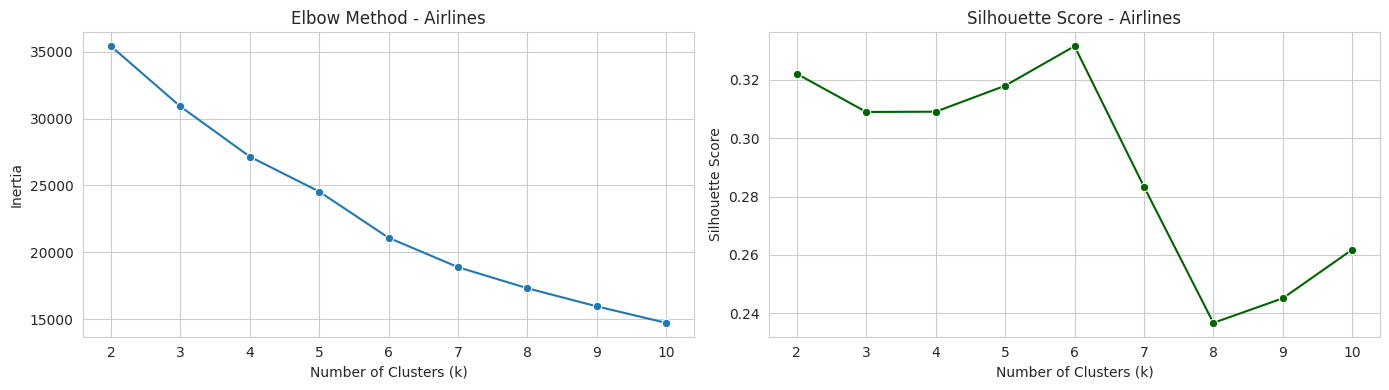

Selected optimal k (max silhouette): 6


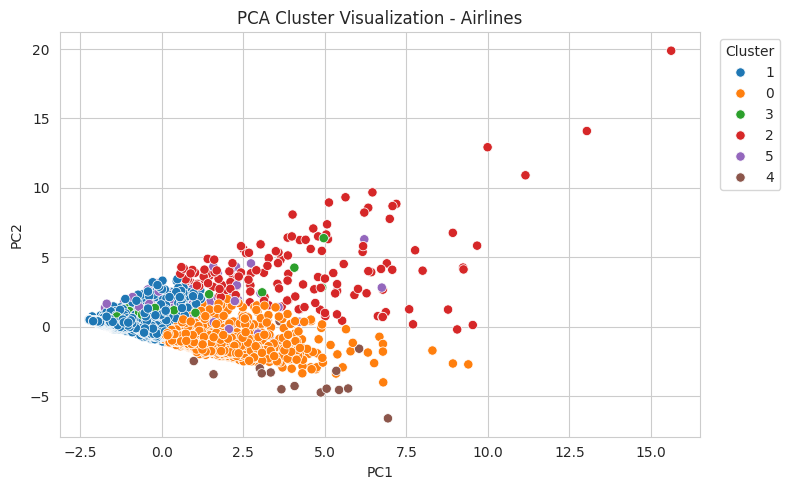

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans
Cluster,,,,,,,,
0,1595.22,117306.66,60.54,3.71,1.00,1.00,39273.75,18.76
1,2238.74,43521.86,42.44,1.23,1.00,1.00,4610.95,6.83
2,1743.87,188155.66,464.57,2.24,1.00,1.00,32995.58,27.98
3,2269.37,68876.58,23.26,1.14,2.35,1.00,14689.84,17.53
4,1664.87,138061.40,78.80,3.47,1.00,4.07,93927.87,28.07
5,2057.30,119660.49,5351.07,2.00,1.00,1.00,18683.48,12.23


,Customer Count
Cluster,
0,1253
1,2484
2,143
3,43
4,15
5,61


In [4]:
air_df = pd.read_excel("EastWestAirlines (1) (1).xlsx", sheet_name="data")
show_basic_info(air_df, "EastWest Airlines")

# Drop identifier column if present
air_features = air_df.drop(columns=[c for c in ["ID#"] if c in air_df.columns]).copy()

# Ensure numeric and fill missing values
for col in air_features.columns:
    air_features[col] = pd.to_numeric(air_features[col], errors="coerce")
air_features = air_features.fillna(air_features.median(numeric_only=True))

scaler_air = StandardScaler()
X_air = scaler_air.fit_transform(air_features)

air_metrics, air_best_k = evaluate_k_values(X_air, k_min=2, k_max=10)
plot_k_selection(air_metrics, "Airlines")
print(f"Selected optimal k (max silhouette): {air_best_k}")

air_clustered = fit_kmeans_and_visualize(X_air, air_df, air_best_k, "Airlines")
profile_clusters(air_clustered)

air_cluster_counts = air_clustered["Cluster"].value_counts().sort_index()
display(air_cluster_counts.to_frame("Customer Count"))

### Q1 Observations

- The selected cluster count is based on the highest silhouette score and elbow trend.
- Clusters generally separate passengers by loyalty balance, transaction activity, and reward usage patterns.
- Business use: design differentiated loyalty campaigns for high-value frequent flyers vs low-engagement customers.

## Q2. Problem Statement 2: Crime Dataset

Apply clustering to group regions based on crime rates and interpret patterns across areas.

Dataset: Crime Data
Shape: (50, 5)


,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,50,50,Alabama,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Murder,50.0,NaN,NaN,NaN,7.788,4.35551,0.8,4.075,7.25,11.25,17.4
Assault,50.0,NaN,NaN,NaN,170.76,83.337661,45.0,109.0,159.0,249.0,337.0
UrbanPop,50.0,NaN,NaN,NaN,65.54,14.474763,32.0,54.5,66.0,77.75,91.0
Rape,50.0,NaN,NaN,NaN,21.232,9.366385,7.3,15.075,20.1,26.175,46.0


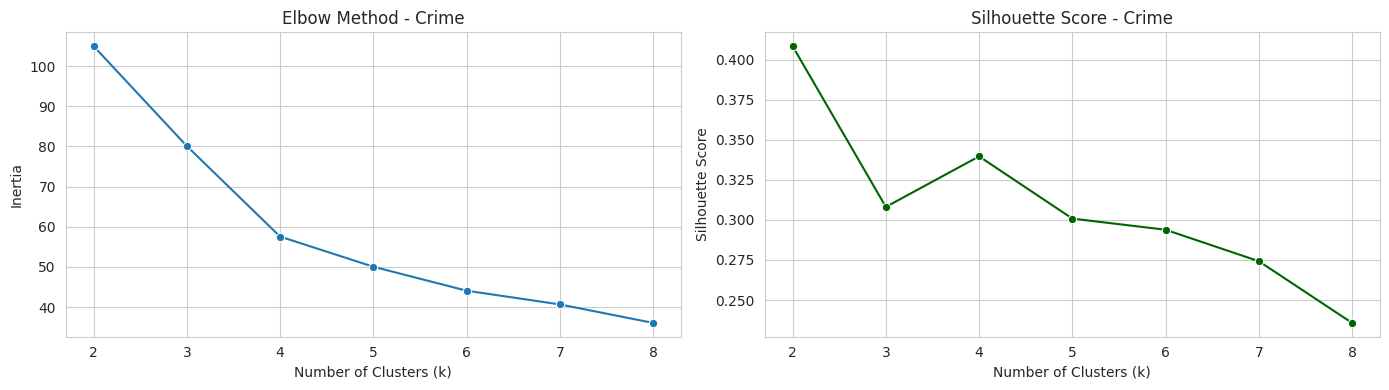

Selected optimal k (max silhouette): 2


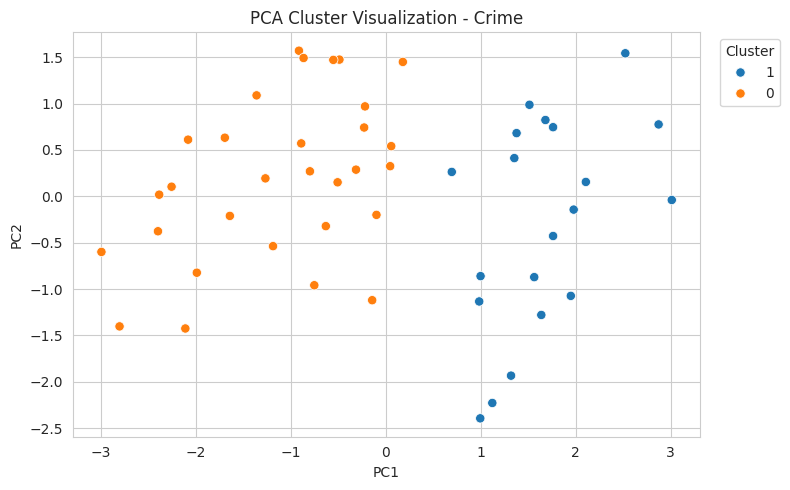

,Murder,Assault,UrbanPop,Rape
Cluster,,,,
0,4.87,114.43,63.63,15.94
1,12.16,255.25,68.40,29.16


,Unnamed: 0
Cluster,
0,Arkansas
1,Alabama


,Region Count
Cluster,
0,30
1,20


,Unnamed: 0,Cluster
3,Arkansas,0
7,Delaware,0
6,Connecticut,0
15,Kansas,0
13,Indiana,0
14,Iowa,0
10,Hawaii,0
11,Idaho,0
25,Montana,0
26,Nebraska,0


In [7]:
crime_df = pd.read_excel("crime_data (1).xlsx")
show_basic_info(crime_df, "Crime Data")

# Keep region/state names separately (first non-numeric column)
region_candidates = crime_df.select_dtypes(exclude=np.number).columns.tolist()
region_col = region_candidates[0] if region_candidates else None

# Use numeric-only features for clustering
crime_features = crime_df.select_dtypes(include=np.number).copy()
for col in crime_features.columns:
    crime_features[col] = pd.to_numeric(crime_features[col], errors="coerce")
crime_features = crime_features.fillna(crime_features.median(numeric_only=True))

scaler_crime = StandardScaler()
X_crime = scaler_crime.fit_transform(crime_features)

crime_metrics, crime_best_k = evaluate_k_values(X_crime, k_min=2, k_max=8)
plot_k_selection(crime_metrics, "Crime")
print(f"Selected optimal k (max silhouette): {crime_best_k}")

crime_clustered = fit_kmeans_and_visualize(X_crime, crime_df, crime_best_k, "Crime")
profile_clusters(crime_clustered)

display(crime_clustered.groupby("Cluster").size().to_frame("Region Count"))
if region_col is not None:
    display(crime_clustered[[region_col, "Cluster"]].sort_values("Cluster").head(20))

### Q2 Observations

- Regions are separated into low, medium, and high crime intensity groups based on standardized crime indicators.
- High-crime clusters can be identified by elevated murder/assault/rape rates.
- Policy use: prioritize targeted interventions and policing resources by cluster severity.

## Q3. Problem Statement 3: Insurance Policy Dataset

Use K-Means to segment policyholders by demographic and policy-related numeric attributes.

Dataset: Insurance Policy
Shape: (100, 5)


,Premiums Paid,Age,Days to Renew,Claims made,Income
0,2800,26,233,3890.076336,28000
1,2950,27,130,2294.444444,29500
2,3100,28,144,2564.545455,31000
3,3250,30,65,1978.260870,32500
4,3400,32,56,2009.090909,34000


,count,mean,std,min,25%,50%,75%,max
Premiums Paid,100.0,12542.250000,6790.731666,2800.00000,6975.000000,11825.000000,15475.00000,29900.00000
Age,100.0,46.110000,13.887641,23.00000,34.000000,45.000000,54.50000,82.00000
Days to Renew,100.0,120.400000,88.055767,1.00000,56.000000,89.000000,186.50000,321.00000
Claims made,100.0,12578.993367,13695.906762,1978.26087,5220.648735,8386.043907,14670.88952,99676.74419
Income,100.0,102250.000000,43517.237964,28000.00000,65125.000000,102250.000000,139375.00000,176500.00000


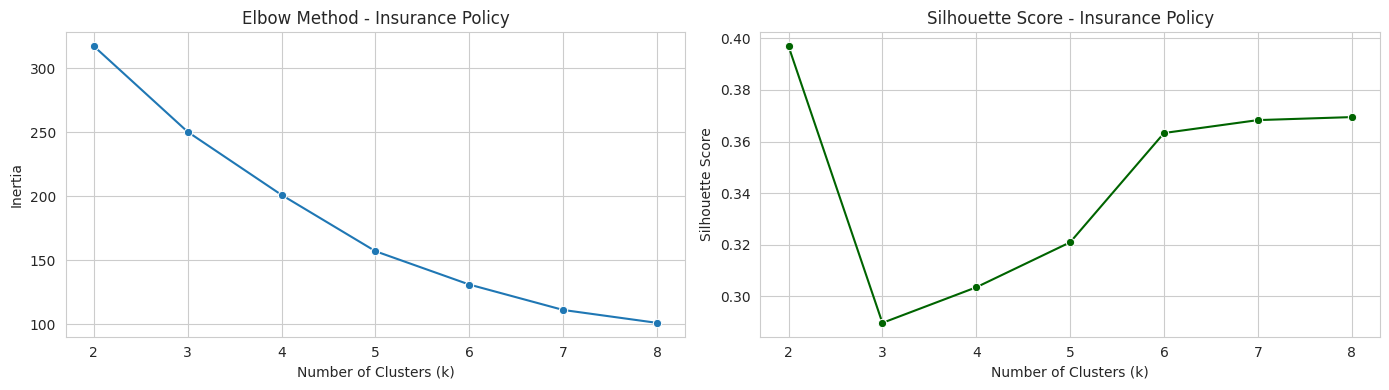

Selected optimal k (max silhouette): 2


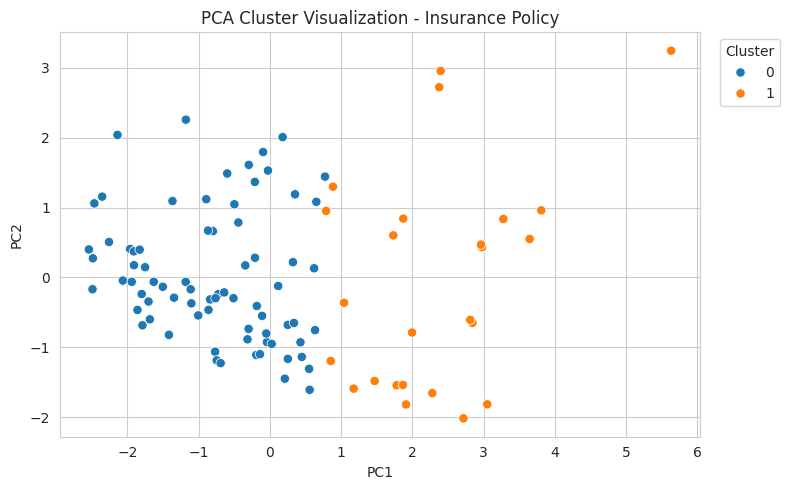

,Premiums Paid,Age,Days to Renew,Claims made,Income
Cluster,,,,,
0,9583.67,41.15,102.73,7527.83,87840.0
1,21418.00,61.00,173.40,27732.49,145480.0


,Customer Count
Cluster,
0,75
1,25


In [6]:
ins_df = pd.read_excel("Insurance Dataset.xlsx")
show_basic_info(ins_df, "Insurance Policy")

ins_features = ins_df.copy()
for col in ins_features.columns:
    ins_features[col] = pd.to_numeric(ins_features[col], errors="coerce")
ins_features = ins_features.fillna(ins_features.median(numeric_only=True))

scaler_ins = StandardScaler()
X_ins = scaler_ins.fit_transform(ins_features)

ins_metrics, ins_best_k = evaluate_k_values(X_ins, k_min=2, k_max=8)
plot_k_selection(ins_metrics, "Insurance Policy")
print(f"Selected optimal k (max silhouette): {ins_best_k}")

ins_clustered = fit_kmeans_and_visualize(X_ins, ins_df, ins_best_k, "Insurance Policy")
profile_clusters(ins_clustered)
display(ins_clustered.groupby("Cluster").size().to_frame("Customer Count"))

### Q3 Observations

- Clusters represent policyholders with similar premium, income, renewal-cycle, and claim behavior.
- One segment usually shows higher claims and premium values, indicating higher risk and higher policy value.
- Business use: design differentiated renewal strategy and claim-monitoring programs by segment.

## Q4. Problem Statement 4: Telecom Customer Churn Dataset

Cluster telecom customers using mixed (categorical + numerical) features to identify segments and churn-related patterns.

Dataset: Telecom Customer Churn
Shape: (7043, 30)


,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,8779-QRDMV,1,Q3,No,0,1,NaN,No,0.00,No,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,7043,7043,8779-QRDMV,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Quarter,7043,1,Q3,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Referred a Friend,7043,2,No,3821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Referrals,7043.0,NaN,NaN,NaN,1.951867,3.001199,0.0,0.0,0.0,3.0,11.0
Tenure in Months,7043.0,NaN,NaN,NaN,32.386767,24.542061,1.0,9.0,29.0,55.0,72.0
Offer,3166,5,Offer B,824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phone Service,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg Monthly Long Distance Charges,7043.0,NaN,NaN,NaN,22.958954,15.448113,0.0,9.21,22.89,36.395,49.99
Multiple Lines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN


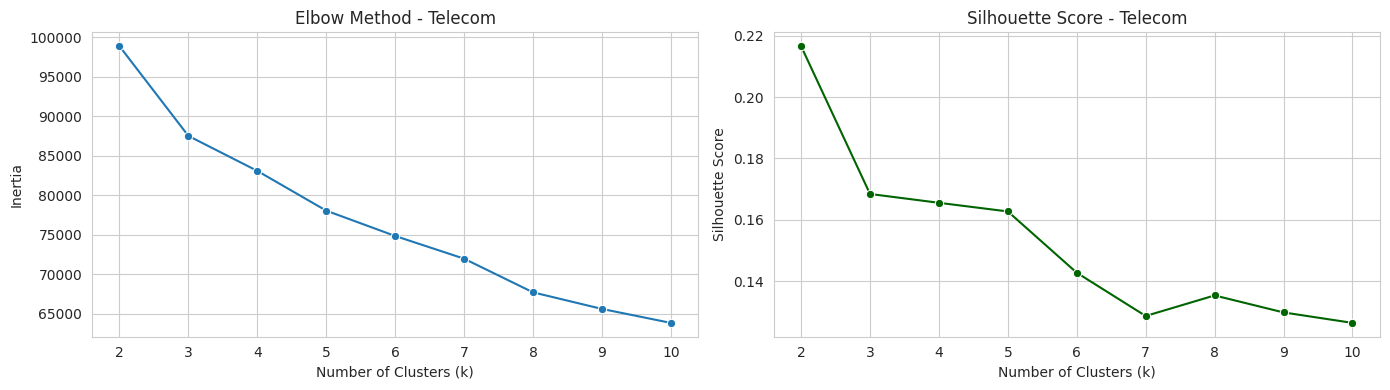

Selected optimal k (max silhouette): 2


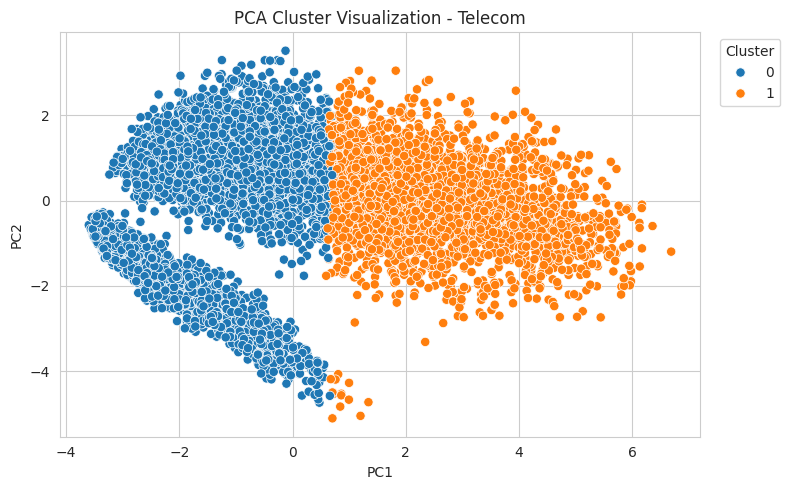

,Count,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds
Cluster,,,,,,,,
0,1.0,1.40,20.31,21.43,16.79,51.84,879.40,1.69
1,1.0,3.01,55.65,25.90,27.69,89.65,4978.73,2.49


,Customer ID,Quarter,Referred a Friend,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method
Cluster,,,,,,,,,,,,,,,,,,,
0,0002-ORFBO,Q3,No,Offer E,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal
1,0013-SMEOE,Q3,Yes,Offer B,Yes,Yes,Yes,Fiber Optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal


,Customer Count
Cluster,
0,4636
1,2407


No explicit churn column found. Segment interpretation can use contract and service variables.


In [8]:
tel_df = pd.read_excel("Telco_customer_churn (1) (1).xlsx")
show_basic_info(tel_df, "Telecom Customer Churn")

# Remove high-cardinality identifier or constant columns when present
drop_cols_tel = [c for c in ["Customer ID", "Count"] if c in tel_df.columns]
tel_model_df = tel_df.drop(columns=drop_cols_tel).copy()

num_cols_tel = tel_model_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_tel = tel_model_df.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

pre_tel = ColumnTransformer([
    ("num", numeric_pipe, num_cols_tel),
    ("cat", categorical_pipe, cat_cols_tel),
])

X_tel = pre_tel.fit_transform(tel_model_df)

tel_metrics, tel_best_k = evaluate_k_values(X_tel, k_min=2, k_max=10, sample_size=2500)
plot_k_selection(tel_metrics, "Telecom")
print(f"Selected optimal k (max silhouette): {tel_best_k}")

tel_clustered = fit_kmeans_and_visualize(X_tel, tel_df, tel_best_k, "Telecom")
profile_clusters(tel_clustered)

display(tel_clustered.groupby("Cluster").size().to_frame("Customer Count"))

# Churn interpretation by segment if churn-like columns exist
churn_like_cols = [c for c in tel_clustered.columns if "churn" in c.lower()]
if churn_like_cols:
    churn_col = churn_like_cols[0]
    churn_profile = (
        tel_clustered.groupby("Cluster")[churn_col]
        .value_counts(normalize=True)
        .rename("ratio")
        .mul(100)
        .round(2)
        .reset_index()
    )
    display(churn_profile)
else:
    print("No explicit churn column found. Segment interpretation can use contract and service variables.")

### Q4 Observations

- Segments capture customer differences in tenure, spend, contract type, payment method, and service bundle choices.
- If churn labels are available in the data, churn ratio by cluster highlights high-risk segments.
- Retention actions: prioritize high-risk clusters with long-term contract offers, value bundles, and proactive support engagement.

## Q5. Problem Statement 5: Auto Insurance Dataset

Perform clustering on mixed auto-insurance data using encoding + normalization and analyze insurance behavior segments.

Dataset: Auto Insurance
Shape: (9134, 24)


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2011-02-24,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,2011-01-31,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2011-02-19,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,2011-01-20,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2011-03-02,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Customer,9134,9134,BU79786,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,9134,5,California,3150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Lifetime Value,9134.0,NaN,NaN,NaN,8004.940475,1898.007675,3994.251794,5780.182197,8962.167041,83325.38119,6870.967608
Response,9134,2,No,7826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coverage,9134,3,Basic,5568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,9134,5,Bachelor,2748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Effective To Date,9134,NaN,NaN,NaN,2011-03-29 07:59:25.316400,2011-01-01 00:00:00,2011-01-25 00:00:00,2011-02-19 00:00:00,2011-05-01 00:00:00,2011-12-02 00:00:00,NaN
EmploymentStatus,9134,5,Employed,5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,9134,2,F,4658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,9134.0,NaN,NaN,NaN,37657.380009,0.0,0.0,33889.5,62320.0,99981.0,30379.904734


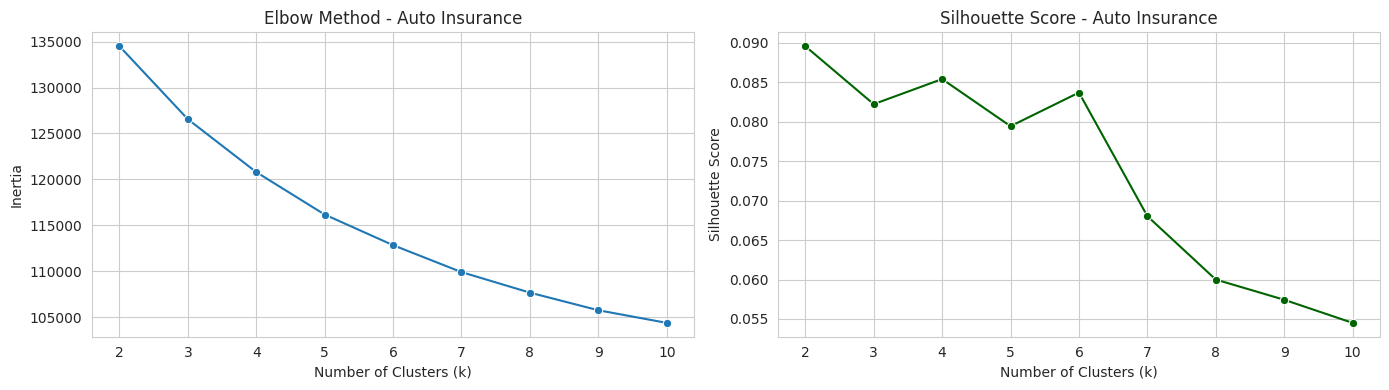

Selected optimal k (max silhouette): 2


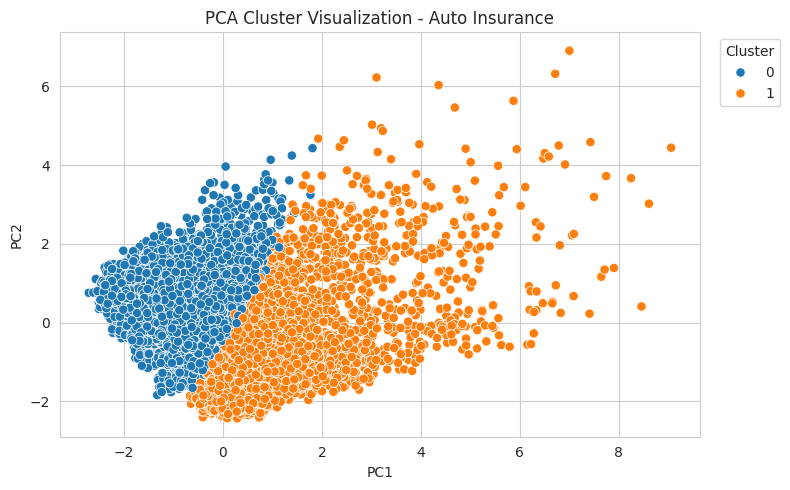

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
Cluster,,,,,,,,
0,6913.81,55109.47,82.99,14.99,48.15,0.39,2.99,286.24
1,9543.47,13049.47,107.64,15.25,47.94,0.38,2.94,642.57


,Customer,State,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size
Cluster,,,,,,,,,,,,,,,,
0,AA11235,California,No,Basic,Bachelor,2011-01-28,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer2,Agent,Four-Door Car,Medsize
1,AA10041,California,No,Basic,High School or Below,2011-01-19,Unemployed,M,Suburban,Single,Personal Auto,Personal L3,Offer1,Agent,Four-Door Car,Medsize


,Customer Count
Cluster,
0,5344
1,3790


,Cluster,Response,ratio
0,0,No,86.3
1,0,Yes,13.7
2,1,No,84.8
3,1,Yes,15.2


In [9]:
auto_df = pd.read_excel("AutoInsurance (1).xlsx")
show_basic_info(auto_df, "Auto Insurance")

# Drop identifier/date-like columns for clustering
auto_model_df = auto_df.drop(columns=[c for c in ["Customer", "Effective To Date"] if c in auto_df.columns]).copy()

num_cols_auto = auto_model_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_auto = auto_model_df.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe_auto = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe_auto = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

pre_auto = ColumnTransformer([
    ("num", numeric_pipe_auto, num_cols_auto),
    ("cat", categorical_pipe_auto, cat_cols_auto),
])

X_auto = pre_auto.fit_transform(auto_model_df)

auto_metrics, auto_best_k = evaluate_k_values(X_auto, k_min=2, k_max=10, sample_size=2500)
plot_k_selection(auto_metrics, "Auto Insurance")
print(f"Selected optimal k (max silhouette): {auto_best_k}")

auto_clustered = fit_kmeans_and_visualize(X_auto, auto_df, auto_best_k, "Auto Insurance")
profile_clusters(auto_clustered)

display(auto_clustered.groupby("Cluster").size().to_frame("Customer Count"))

# Response distribution by cluster (campaign acceptance tendency)
if "Response" in auto_clustered.columns:
    response_profile = (
        auto_clustered.groupby("Cluster")["Response"]
        .value_counts(normalize=True)
        .rename("ratio")
        .mul(100)
        .round(2)
        .reset_index()
    )
    display(response_profile)

### Q5 Observations

- Mixed-feature clustering reveals behavior-driven segments by premium, claim amount, policy type, channel, and demographics.
- Segments with high claim amount and high premium can be managed with risk-sensitive pricing and retention offers.
- Segments with low engagement/response can be targeted with channel-specific campaigns and simplified policy bundles.

## Final Conclusion

- K-Means successfully segments all five datasets into meaningful customer/region groups.
- Optimal cluster counts are selected using both elbow trend and silhouette score.
- The resulting cluster profiles support practical decisions in loyalty management, crime control, customer retention, and insurance strategy.